In [3]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from IPython.core.magic import register_line_cell_magic
import yaml
from PIL import Image
import os
import seaborn as sns
from ultralytics import YOLO
from matplotlib.patches import Rectangle
import glob
import cv2

In [2]:
warnings.filterwarnings("ignore")

np.random.seed(12345)

%matplotlib inline

!wandb disabled

'wandb' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
INPUT_DIR = 'D:/project/CDIO/dataset'
WORK_DIR = 'D:/project/CDIO'

In [4]:
num_classes = 10
classes = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']

In [ ]:
dict_file = {'train': os.path.join(INPUT_DIR, 'train'),
             'val': os.path.join(INPUT_DIR, 'valid'),
             'nc': num_classes,
             'names': classes
            }

with open(os.path.join(WORK_DIR, 'data.yaml'), 'w+') as file:
    yaml.dump(dict_file, file)

In [6]:
class_idx = {str(i):classes[i] for i in range(num_classes)}

class_stat = {}
data_len = {}

for mode in ['train', 'valid', 'test']:

    class_count = {classes[i]:0 for i in range(num_classes)}

    path = os.path.join(INPUT_DIR, mode, 'labels')

    for file in os.listdir(path):

        if file.endswith(".txt"):
            with open(os.path.join(path, file)) as f:
                lines = f.readlines()

                for cls in set([line[0] for line in lines]):
                    class_count[class_idx[cls]] += 1
                
    data_len[mode] = len(os.listdir(path))
    class_stat[mode] = class_count

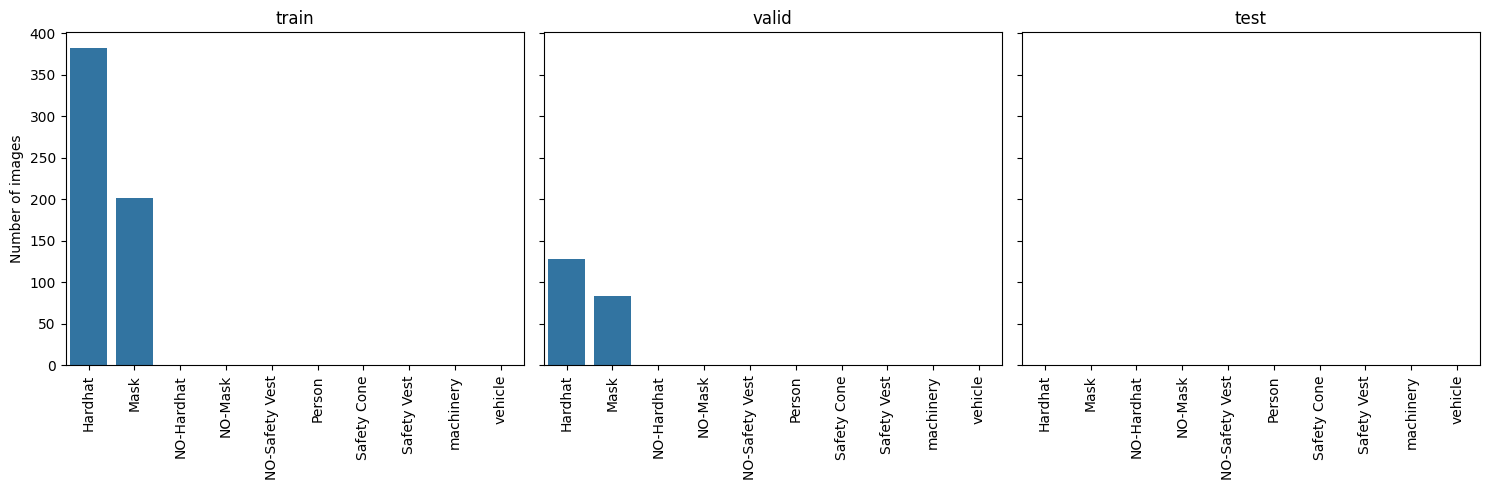

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, mode in enumerate(['train', 'valid', 'test']):
    values = list(class_stat[mode].values())
    labels = list(class_stat[mode].keys())
    
    sns.barplot(x=labels, y=values, ax=ax[i])
    ax[i].set_title(mode)
    ax[i].tick_params(axis='x', rotation=90)
    ax[i].set_ylabel('Number of images')

plt.tight_layout()
plt.show()

In [8]:
for mode in ['train', 'valid', 'test']:
    print(mode)
    print(class_stat[mode])

train
{'Hardhat': 382, 'Mask': 202, 'NO-Hardhat': 0, 'NO-Mask': 0, 'NO-Safety Vest': 0, 'Person': 0, 'Safety Cone': 0, 'Safety Vest': 0, 'machinery': 0, 'vehicle': 0}
valid
{'Hardhat': 128, 'Mask': 83, 'NO-Hardhat': 0, 'NO-Mask': 0, 'NO-Safety Vest': 0, 'Person': 0, 'Safety Cone': 0, 'Safety Vest': 0, 'machinery': 0, 'vehicle': 0}
test
{'Hardhat': 0, 'Mask': 0, 'NO-Hardhat': 0, 'NO-Mask': 0, 'NO-Safety Vest': 0, 'Person': 0, 'Safety Cone': 0, 'Safety Vest': 0, 'machinery': 0, 'vehicle': 0}


In [ ]:
for mode in['train', 'valid', 'test']:
    print(f'\nImage sizes in {mode} set: \n')
    img_size = 0
    for file in glob.glob(os.path.join(INPUT_DIR, mode, 'images', '*')):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image = Image.open(file)

            if image.size != img_size:
                print(f'\t{image.size}')
                img_size = image.size
0


Image sizes in train set: 

	(640, 640)

Image sizes in valid set: 

	(640, 640)

Image sizes in test set: 

	(640, 640)


In [10]:
for mode in ['train', 'valid', 'test']:
    files = glob.glob(os.path.join(INPUT_DIR, mode, 'images', '*'))

    print(f'{mode} set size: {len(files)}\n')

train set size: 153

valid set size: 175

test set size: 134



In [4]:
model = YOLO('yolov8n.pt')

In [ ]:
model.train(data =r"D:\project\CDIO\data.yaml",
            task ='detect',
            imgsz=640,
            epochs=20,
            batch=32,
            mode= 'train',
            name = 'yolov8n_v1_train')

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.12.8 torch-2.8.0+cpu CPU (Intel Core i7-9750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\project\CDIO\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_v1_train3,

In [ ]:
model = YOLO('runs/detect/yolov8n_v1_train/weights/best.pt')

In [ ]:
results = model.predict(source=os.path.join(INPUT_DIR, 'test', 'images'), conf= 0.01, save = True)


image 1/134 D:\project\CDIO\dataset\test\images\1-10-_jpg.rf.7a5c26cc56c7b6eb2dc3fe52a412b465.jpg: 640x640 (no detections), 77.5ms
image 2/134 D:\project\CDIO\dataset\test\images\1-15-_jpg.rf.9d6c8a802412c5cd8d655a40d22bfa0e.jpg: 640x640 1 Mask, 96.7ms
image 3/134 D:\project\CDIO\dataset\test\images\1-18-_jpg.rf.cfddaf09394c3b3acc744d779c5db65d.jpg: 640x640 2 Hardhats, 2 Masks, 77.3ms
image 4/134 D:\project\CDIO\dataset\test\images\1-3-_jpg.rf.49b4a723033a59572aa8d914888639e8.jpg: 640x640 1 Hardhat, 1 Mask, 103.4ms
image 5/134 D:\project\CDIO\dataset\test\images\1-33-_jpg.rf.7ecef2b8fa0142081399ed3a0707f6ec.jpg: 640x640 (no detections), 74.1ms
image 6/134 D:\project\CDIO\dataset\test\images\1-41-_jpg.rf.796850fad947c4772aa2cb54b7a45d0a.jpg: 640x640 1 Hardhat, 2 Masks, 90.3ms
image 7/134 D:\project\CDIO\dataset\test\images\1-48-_jpg.rf.5595c893323af8db40f43b5e29b389cf.jpg: 640x640 2 Hardhats, 4 Masks, 87.0ms
image 8/134 D:\project\CDIO\dataset\test\images\1-56-_jpg.rf.14efebb8d09aef8ca

In [ ]:
%matplotlib inline

predict_folders = glob.glob(os.path.join(WORK_DIR, 'runs/detect/predict*'))

if not predict_folders:
    print("Chưa có kết quả predict")
else:
    latest = sorted(predict_folders)[-1]
    print("Dùng folder:", latest)

    predictions = glob.glob(os.path.join(latest, '*'))
    predictions = [f for f in predictions if f.lower().endswith(('.jpg', '.png'))]

    print("Số ảnh:", len(predictions))

Dùng folder: D:/project/CDIO\runs/detect\predict
Số ảnh: 134
